In [18]:
# Import our libraries 

# Pandas and numpy for data wrangling
import pandas as pd
import numpy as np
# Seaborn / matplotlib for visualization 
import seaborn as sns

# Import the trees from sklearn
from sklearn import tree

# Helper function to split our data
from sklearn.model_selection import train_test_split


# Helper fuctions to evaluate our model.
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, f1_score


# Helper function for hyper-parameter turning.
from sklearn.model_selection import GridSearchCV


# Import our Decision Tree
from sklearn.tree import DecisionTreeClassifier 


# Import our Random Forest 
from sklearn.ensemble import RandomForestClassifier

# Use inline so our visualizations display in notebook
%matplotlib inline

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

## Main Steps when building a Machine Learning Model. 
1. Inspect and explore data.
2. Select and engineer features.
3. Build and train model.
4. Evaluate model.

# #1 Inspect and explore data.
* Load titanic data
* Visualize all the data using sns.pairplot
* Check for null values

In [4]:
# Load in the titanic data set.
df = pd.read_csv('/workspaces/ds-fall-2025-fri-1230/Week-09-Trees/data/titanic.csv')


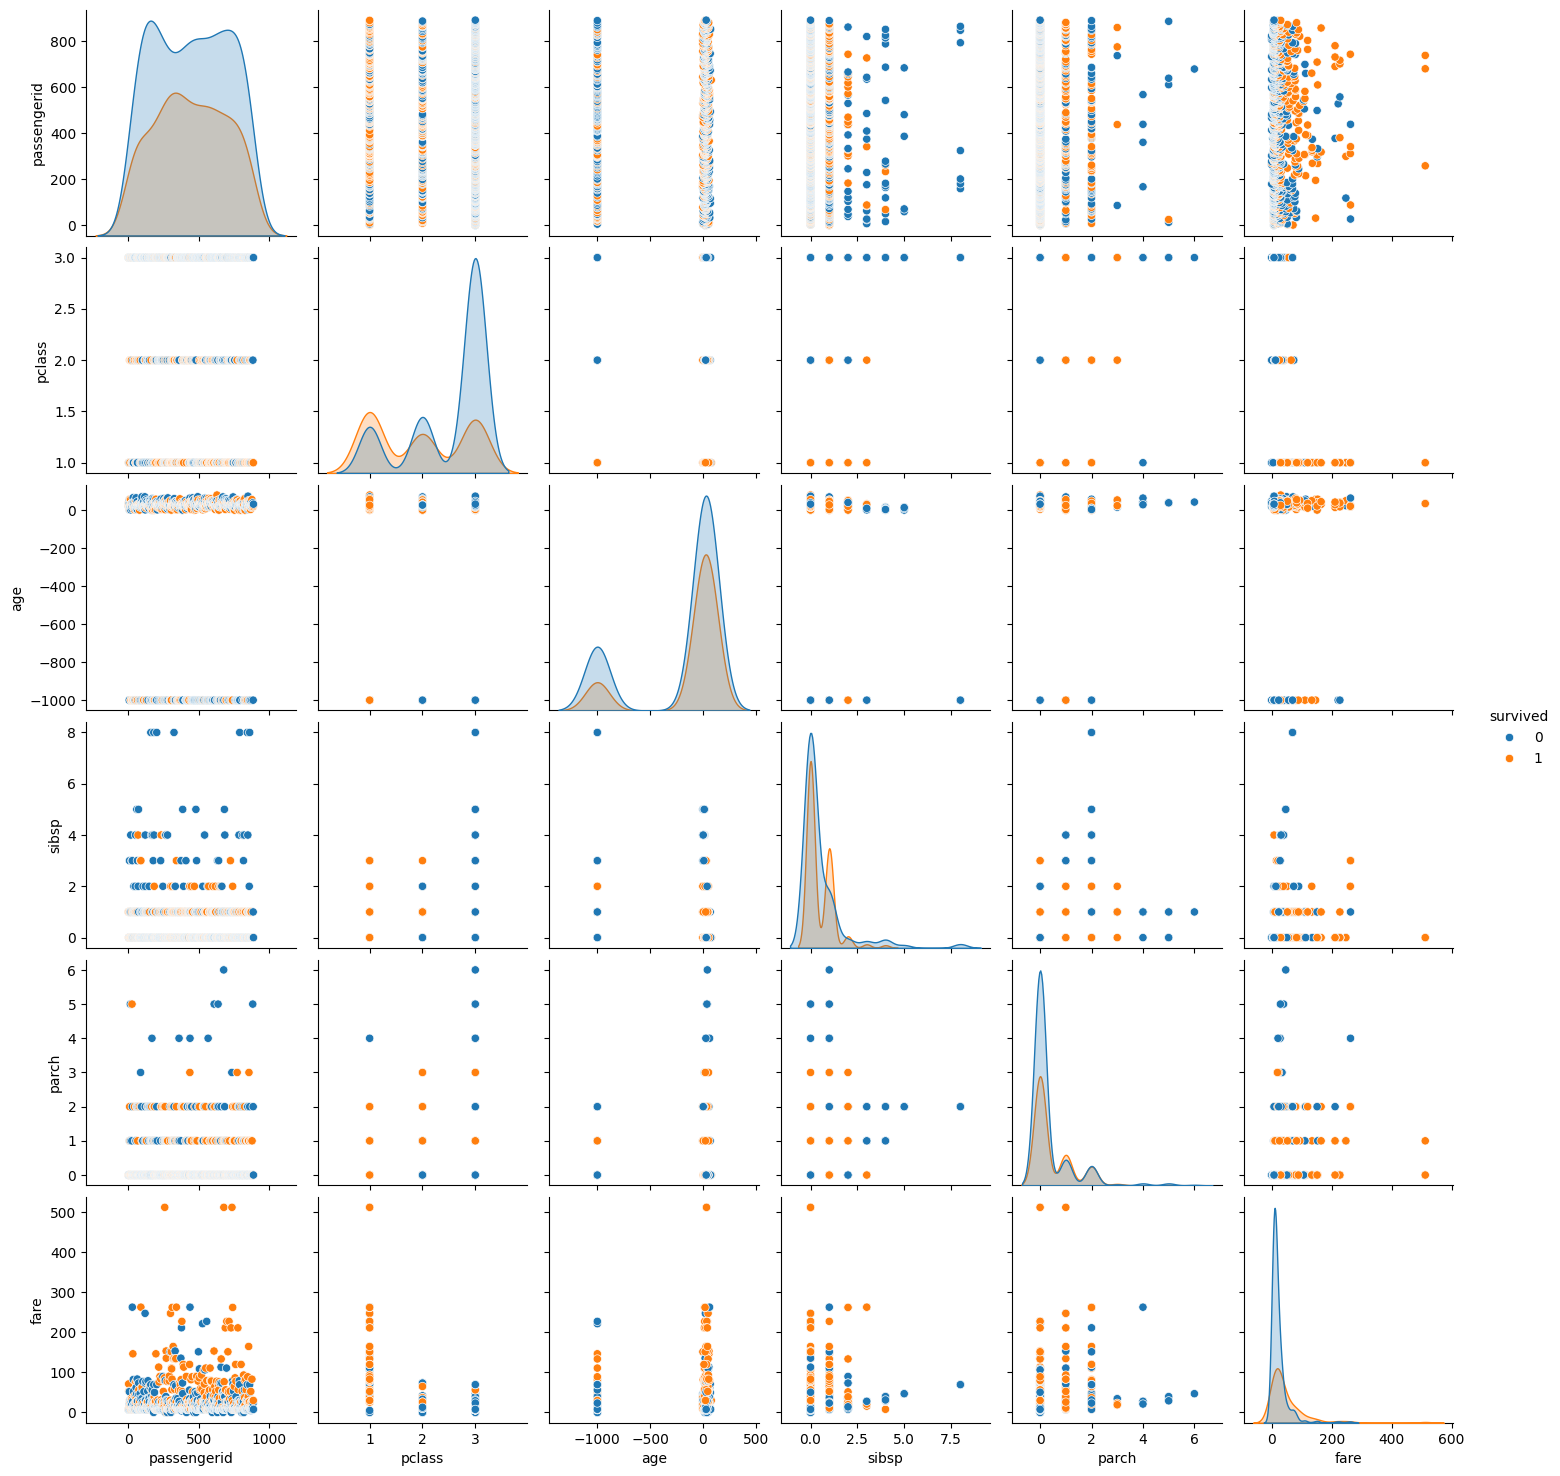

In [8]:
# Visualize all the data using sns.pairplot
# t_visual=sns.pairplot(df)
sns.pairplot(df, hue='survived');


In [6]:
# Check for null values
df.isnull().sum()


passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

# #2 Select and engineer features.
1. Fill age null values with -999
1. Convert to numerical values if need be by using `pd.get_dummies()`
1. Create a list of the features you are going to use.  In this case use as many or as little as you would like.
1. Define our `X` and `y`
1. Split our data into trainig and testing sets.

In [7]:
# Fill age null values with -999
df['age'] = df['age'].fillna(-999)


In [9]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# 1. Convert to numerical values if need be by using `pd.get_dummies()`
df = pd.get_dummies(df, columns=['sex', 'pclass','sex', 'embarked'], drop_first=True)


In [47]:
# 2. Create a list of the features we are going to use.
selected_features = ['fare', 'age',  
                     'sex_male', 'pclass_2', 'pclass_3',  
                     'sibsp', 'parch', 'embarked_Q','embarked_S'] 
#list(df.columns)
#['sex','fare','age','sibsp','survived']
print(selected_features, "length: ", len(selected_features))

['fare', 'age', 'sex_male', 'pclass_2', 'pclass_3', 'sibsp', 'parch', 'embarked_Q', 'embarked_S'] length:  9


In [13]:
# Define our `X` and `y`
independent_variables = ['fare', 'age',  
                     'sex_male', 'pclass_2', 'pclass_3',  
                     'sibsp', 'parch', 'embarked_Q','embarked_S']
dependent_variable = 'survived'



In [14]:
# Split our data into trainig and testing sets.
X_var = df[independent_variables]
y = df[dependent_variable]

X_train, X_test, y_train, y_test = train_test_split(X_var, y, stratify=y, test_size=0.2, random_state=45)

print('Lenght of our Training data:', X_train.shape, '\nLength of our Testing data:',  y_test.shape)

Lenght of our Training data: (712, 10) 
Length of our Testing data: (179,)


# #3 Build and train model.
1. For our first pass, initialize our model with `max_depth=2`.
2. Fit our model with our training data. 
3. Make predictions of our testing data. 
4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
    * To calculate auc score you have to get the predicted probabilites for the Survived class using `model.predict_proba(X_test)[:,1]`
5. Visualize our Decision Tree using provided code. 


In [15]:
# For our first pass, initialize our model with `max_depth=2`.

model = DecisionTreeClassifier(max_depth=2)


In [16]:
# Fit our model with our training data. 

model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


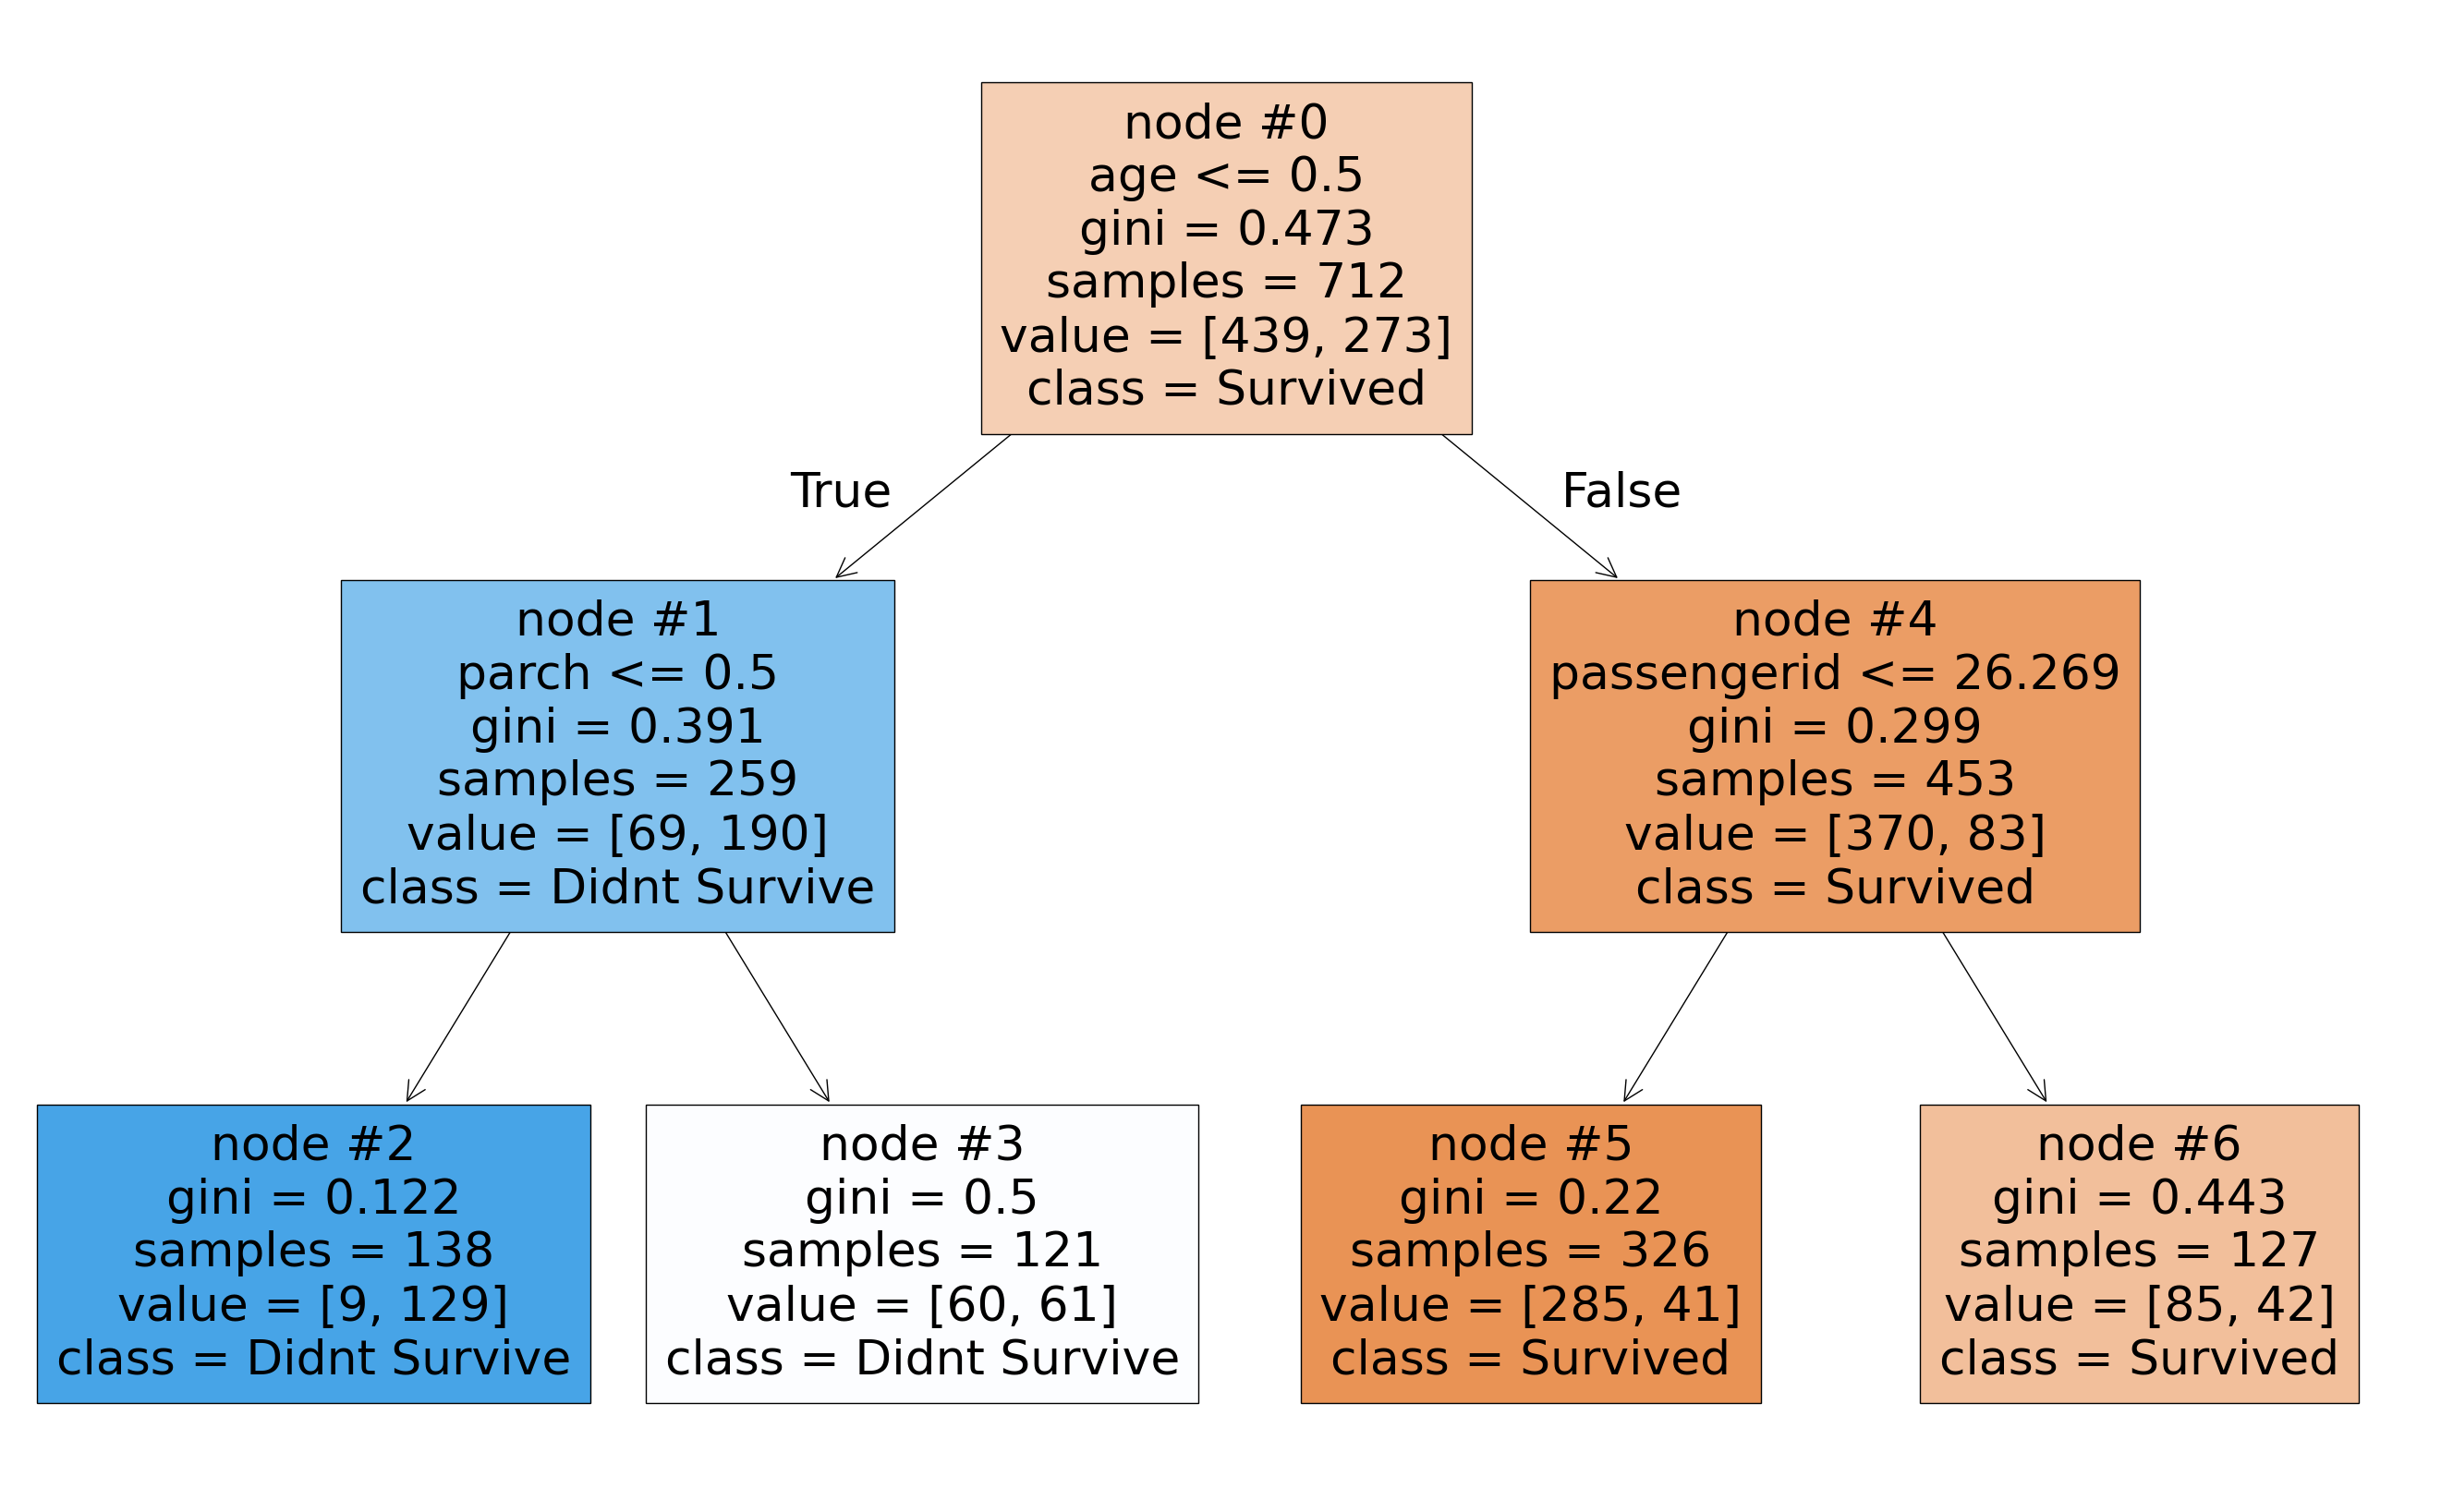

In [19]:
# Make predictions of our testing data. 


y_pred = model.predict(X_test)
plt.figure(figsize=(34,21))
ivs=list(df.columns)
plot_tree(model, node_ids=True, feature_names=ivs, class_names=['Survived', 'Didnt Survive'], filled=True);


In [20]:
# 4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_true=y_test, y_pred=y_pred)
print("Precision Score: %f" % precision)

recall = recall_score(y_true=y_test, y_pred=y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_true=y_test, y_pred=y_pred)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities
y_pred_proba = model.predict_proba(X_test)

# Keep only the proba for True
y_pred_proba = y_pred_proba[:,1]

# Compute auc score
auc = roc_auc_score(y_true=y_test, y_score=y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.787709
Precision Score: 0.781818
Recall Score: 0.623188
F1 Score: 0.693548
AUC Score: 0.828590


# Visualize your tree

# Picking the right parameters...

# Parameter tuning of your Decision Tree using GridSearch or RandomizedSearch

### For assistance on this, look at Steves TA Tips code in `TA-Tips/random_forest_tuning.ipynb`


1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Visualize your best tree.
1. Which feature was your most important feature?

```python
tree.DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    class_weight=None,
    presort='deprecated',
    ccp_alpha=0.0,
)
```


[Tips on how to customize / set the paramters in the decision tree.](https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use)

In [34]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search.from sklearn.model_selection import GridSearchCV

params = {
    'max_leaf_nodes': [2, 8, 32], 
    'max_depth': [1, 3, 5],
    'min_samples_leaf': [5, 20, 80],
}

In [35]:
# 1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
clf = DecisionTreeClassifier(criterion='gini')
grid_search_cv =  GridSearchCV(clf,params,cv=2)


In [36]:
# 1. Fit your GridSearchCV with your training data.
grid_search_cv.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [1, 3, ...], 'max_leaf_nodes': [2, 8, ...], 'min_samples_leaf': [5, 20, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [37]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print("Best Parameters:", grid_search_cv.best_params_)


Best Parameters: {'max_depth': 3, 'max_leaf_nodes': 8, 'min_samples_leaf': 5}


In [39]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

# This command gives you the best tree
model = DecisionTreeClassifier(max_depth=3, max_leaf_nodes=8,min_samples_leaf=5)
model.fit(X_train,y_train)


# Now lets evaluate our model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_true=y_test, y_pred=y_pred)

print("Precision Score: %f" % precision)

recall = recall_score(y_true=y_test, y_pred=y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_true=y_test, y_pred=y_pred)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1

y_pred_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_true=y_test, y_score=y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.810056
Precision Score: 0.843137
Recall Score: 0.623188
F1 Score: 0.716667
AUC Score: 0.847497


In [53]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_names=selected_features 
class_names=['died', 'survived']
target_name = 'survived'
# print("X_train shape:", X_train.shape)
# print("Number of model features:", len(model.feature_importances_))
# print("Selected features:", selected_features)
# print("Count:", len(selected_features))
# selected_features = X_train.columns.tolist()

# print(len(model.feature_importances_))
# print(len(selected_features))
# print(model.feature_importances_)
feature_imp = pd.DataFrame.from_dict( {'feature_importance': model.feature_importances_,
                                       'feature':selected_features }).sort_values('feature_importance', ascending=False)
feature_imp

,feature_importance,feature
3,0.673912,sex_male
5,0.161433,pclass_3
0,0.109165,fare
6,0.043697,sibsp
7,0.011793,parch
1,0.000000,age
4,0.000000,pclass_2
2,0.000000,sex_male
8,0.000000,embarked_Q
9,0.000000,embarked_S


# Now onto Random Forests...
Were going to do the same with, but this time with a random forest. Remeber... Repetition is the father of learning.

1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Which feature was your most important feature?


# Parameters of the Random Forest Classifier

```python
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='auto',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
)
```

In [96]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
params = {
    'min_impurity_decrease': [.1, .2, .5], 
    'min_samples_leaf': [20, 40 , 100],
    'max_leaf_nodes': [2, 4, 8],
}

In [97]:
# 1. Initalize your GridSearchCV or RandomizedSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.

rcf_1 = RandomForestClassifier(criterion='gini')
grid_search_cv_rf =  GridSearchCV(rcf_1,params,cv=2)


In [98]:
# 1. Fit your GridSearchCV with your training data. 
grid_search_cv_rf.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_leaf_nodes': [2, 4, ...], 'min_impurity_decrease': [0.1, 0.2, ...], 'min_samples_leaf': [20, 40, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [99]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print("Best Parameters:", grid_search_cv_rf.best_params_)





Best Parameters: {'max_leaf_nodes': 4, 'min_impurity_decrease': 0.1, 'min_samples_leaf': 40}


In [100]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

# This command gives you tree that has the highest f1-score. 
model = grid_search_cv_rf.best_estimator_


# Now lets evaluate our model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_true=y_test, y_pred=y_pred)
print("Precision Score: %f" % precision)

recall = recall_score(y_true=y_test, y_pred=y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_true=y_test, y_pred=y_pred)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_true=y_test, y_score=y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.818182
Precision Score: 0.909091
Recall Score: 0.740741
F1 Score: 0.816327
AUC Score: 0.922840


In [101]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_imp = pd.Series(model.feature_importances_,index=selected_features).sort_values(ascending=False)
feature_imp

elevation         0.696429
price_per_sqft    0.303571
beds              0.000000
price             0.000000
bath              0.000000
sqft              0.000000
year_built        0.000000
dtype: float64

# Build a random forest using the ny-vs-sf-housing.csv data. 
* Your target variable, aka the column you are trying to predict, aka your `y` variable is `in_sf`. 
* Can you get an accuracy above %88.8889?
* What was your most important feature?


In [102]:
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10


In [103]:
df = pd.read_csv('/workspaces/ds-fall-2025-fri-1230/Week-09-Trees/data/ny-vs-sf-houses.csv')


df.head()

df.isnull().sum()

independent_var=['beds', 'bath', 'price', 'year_built', 'sqft',
       'price_per_sqft', 'elevation']
print(df.columns)
dependent_var='in_sf'
X_var1 = df[independent_var]
y1 = df[dependent_var]
X_train, X_test, y_train, y_test = train_test_split(X_var1, y1, stratify=y1, test_size=0.2, random_state=45)
print('Lenght of our Training data:', X_train.shape, '\nLength of our Testing data:',  y_test.shape)
model = RandomForestClassifier(max_depth=2)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
selected_features = X_train.columns.tolist()

params = {
    'min_impurity_decrease': [.1, .2, .5], 
    'min_samples_leaf': [20, 40 , 100],
    'max_leaf_nodes': [2, 4, 8],
}

rcf_1 = RandomForestClassifier(criterion='gini')
grid_search_cv_rf =  GridSearchCV(rcf_1,params,cv=2)
grid_search_cv_rf.fit(X_train,y_train)
print("Best Parameters:", grid_search_cv_rf.best_params_)
print("X_train shape:", X_train.shape)
print("Number of model features:", len(model.feature_importances_))

print("Selected features:", selected_features)
print("Count:", len(selected_features))

Index(['in_sf', 'beds', 'bath', 'price', 'year_built', 'sqft',
       'price_per_sqft', 'elevation'],
      dtype='object')
Lenght of our Training data: (393, 7) 
Length of our Testing data: (99,)
Best Parameters: {'max_leaf_nodes': 4, 'min_impurity_decrease': 0.1, 'min_samples_leaf': 20}
X_train shape: (393, 7)
Number of model features: 7
Selected features: ['beds', 'bath', 'price', 'year_built', 'sqft', 'price_per_sqft', 'elevation']
Count: 7


In [104]:
# BUILD, TRAIN, AND EVAULATE A RANDOM FOREST MODEL BELOW. 
model = grid_search_cv_rf.best_estimator_

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_true=y_test, y_pred=y_pred)
print("Precision Score: %f" % precision)

recall = recall_score(y_true=y_test, y_pred=y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_true=y_test, y_pred=y_pred)
print('F1 Score: %f' % f1)

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_true=y_test, y_score=y_pred_proba)
print('AUC Score: %f' % auc)

feature_imp = pd.Series(model.feature_importances_,index=selected_features).sort_values(ascending=False)
feature_imp


Accuracy Score: 0.909091
Precision Score: 0.924528
Recall Score: 0.907407
F1 Score: 0.915888
AUC Score: 0.931070


elevation         0.555556
price_per_sqft    0.444444
beds              0.000000
price             0.000000
bath              0.000000
sqft              0.000000
year_built        0.000000
dtype: float64

# Awesome difficult extra credit below:
Build a classifier using the adult_income.csv data.  
* The target variable is 'class'
* Start with just using these features `selected_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']`
* You have to include the pos_label in your precision, recall, and f1 scores. It just tells the classifier which one is the posotive label.  I provided the proper way below.

* See if you can get above 50% f1 score.  
* See some [super tricks and tips here](https://www.kaggle.com/code/jieyima/income-classification-model)

In [105]:
df = pd.read_csv('/workspaces/ds-fall-2025-fri-1230/Week-09-Trees/data/adult_income.csv')

df.head()
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'class'],
      dtype='object')


In [107]:
# df.isnull().sum()
# df.head()

# df['workclass_1'] = df['workclass'].astype('category').cat.codes
# df['education_1'] = df['education'].astype('category').cat.codes
# df['education_1'] = df['education'].astype('category').cat.codes
# df['education_num_1'] = df['education'].astype('category').cat.codes